In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv(r"C:\Users\Y.PHANI MANJUNATH\OneDrive\Desktop\ML_PROJECT\fraud-detection\data\creditcard.csv")

In [3]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
import matplotlib.pyplot as plt

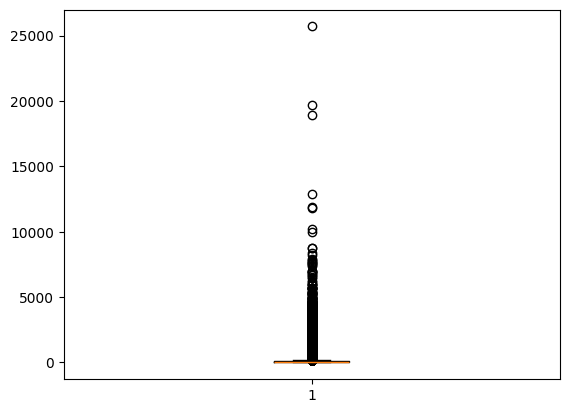

In [10]:
plt.boxplot(df.Amount)
plt.show()

In [11]:
Q1 = df['Amount'].quantile(0.25)
Q3 = df['Amount'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Amount'] < lower) | (df['Amount'] > upper)]

print("Number of outliers:", len(outliers))

Number of outliers: 31904


In [12]:
X=df.drop('Class',axis=1)
y=df['Class']

In [13]:
print(X.shape,y.shape,sep="\n")

(284807, 30)
(284807,)


In [15]:
print(len(df[df['Class']==0]))

284315


In [16]:
scaler=RobustScaler()

In [18]:
X['Amount']=scaler.fit_transform(X[['Amount']])
X['Time']=scaler.fit_transform(X[['Time']])

In [19]:
X['Amount'].describe()

count    284807.000000
mean          0.927124
std           3.495006
min          -0.307413
25%          -0.229162
50%           0.000000
75%           0.770838
max         358.683155
Name: Amount, dtype: float64

{'whiskers': [<matplotlib.lines.Line2D at 0x163a6ac9250>,
 'caps': [<matplotlib.lines.Line2D at 0x163a70b10d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x163a6aca5d0>],
 'medians': [<matplotlib.lines.Line2D at 0x163a6ac8ce0>],
 'fliers': [<matplotlib.lines.Line2D at 0x163a6ac8860>],
 'means': []}

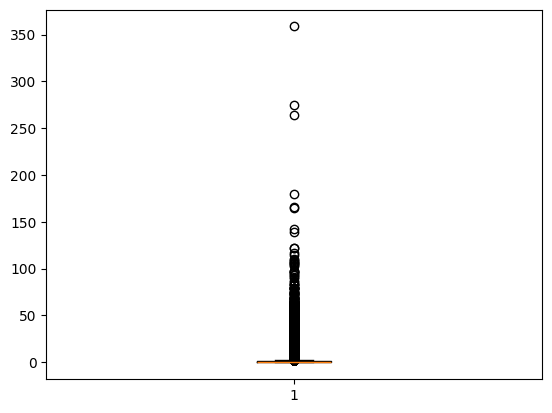

In [20]:
plt.boxplot(X['Amount'])

In [30]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [31]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("\nFraud in train:", y_train.sum())
print("Fraud in test:", y_test.sum())

X_train shape: (227845, 30)
X_test shape: (56962, 30)

Fraud in train: 394
Fraud in test: 98


In [32]:
smote=SMOTE(random_state=42)
X_smote,y_smote=smote.fit_resample(X_train,y_train)

In [39]:
(y_train==1).sum()

np.int64(394)

In [42]:
(y_smote==1).sum()

np.int64(227451)

In [44]:
import os
os.getcwd()

'C:\\Users\\Y.PHANI MANJUNATH\\OneDrive\\Desktop\\ML_PROJECT\\fraud-detection\\notebooks'

In [46]:
import joblib
import numpy as np
import os

# Create models folder if not exists
os.makedirs(r"C:\Users\Y.PHANI MANJUNATH\OneDrive\Desktop\ML_PROJECT\fraud-detection\models", exist_ok=True)


joblib.dump(scaler, r"C:\Users\Y.PHANI MANJUNATH\OneDrive\Desktop\ML_PROJECT\fraud-detection\models\scaler.pkl")


np.save(r"C:\Users\Y.PHANI MANJUNATH\OneDrive\Desktop\ML_PROJECT\fraud-detection\models\X_train.npy", X_smote)
np.save(r"C:\Users\Y.PHANI MANJUNATH\OneDrive\Desktop\ML_PROJECT\fraud-detection\models\X_test.npy", X_test)
np.save(r"C:\Users\Y.PHANI MANJUNATH\OneDrive\Desktop\ML_PROJECT\fraud-detection\models\y_train.npy", y_smote)
np.save(r"C:\Users\Y.PHANI MANJUNATH\OneDrive\Desktop\ML_PROJECT\fraud-detection\models\y_test.npy", y_test)



In [1]:
# Check column order
cols = df.drop('Class', axis=1).columns.tolist()
print(cols)
print("Time index:", cols.index('Time'))
print("Amount index:", cols.index('Amount'))

NameError: name 'df' is not defined